In [135]:
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt

os.makedirs('img', exist_ok=True)
os.getcwd()

'/home/van/test_metad/pt/pm3-2d/fes'

In [137]:

outname="freefiles/freefile"
nstlim=1000 # ps
n_hills=500
timestep=0.001 #fs -- 0.001


data shape:  (5852, 5)


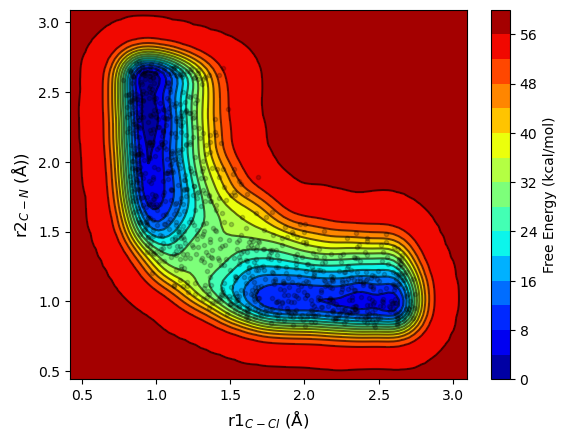

In [138]:
dist_data = np.loadtxt(f'../COLVAR', comments="#")

stride=100
ccl = dist_data[::stride,1]
cn = dist_data[::stride,2]

data = np.loadtxt(f'{outname}.dat', comments="#")
print('data shape: ', data.shape)

r1 = data[:,0] 
r2 = data[:,1] 
fes = data[:,2] 

r1_vals = np.unique(r1)
r2_vals = np.unique(r2)
F = np.full((len(r1_vals), len(r2_vals)), np.nan)

r1_index = {v:i for i, v in enumerate(r1_vals)}
r2_index = {v:i for i, v in enumerate(r2_vals)}

for x,y,z in zip(r1, r2, fes):
    F[r1_index[x], r2_index[y]] = z

# cp_lines = plt.contour(r1_vals, r2_vals, F.T, levels=np.arange(0,30,0.2))
cbar_stride=4
cp = plt.contourf(r1_vals, r2_vals, F.T, cmap='jet', levels=np.arange(0,np.max(fes)+5, cbar_stride))
cp_lines = plt.contour(r1_vals, r2_vals, F.T, colors='black', levels=np.arange(0,np.max(fes)+5, cbar_stride), alpha=0.6)
plt.colorbar(cp, cmap='jet', label='Free Energy (kcal/mol)')

plt.plot(ccl, cn, '.', alpha=0.2, color='black')

plt.xlabel('r1$_{C-Cl}$ (Å)', fontsize=12)
plt.ylabel('r2$_{C-N}$ (Å))', fontsize=12)
plt.savefig('img/fes.png', dpi=300)




found files:  ['freefiles/freefile_timedep0.dat', 'freefiles/freefile_timedep1.dat', 'freefiles/freefile_timedep2.dat', 'freefiles/freefile_timedep3.dat', 'freefiles/freefile_timedep4.dat', 'freefiles/freefile_timedep5.dat', 'freefiles/freefile_timedep6.dat', 'freefiles/freefile_timedep7.dat', 'freefiles/freefile_timedep8.dat', 'freefiles/freefile_timedep9.dat']
data shape:  (5852, 5)


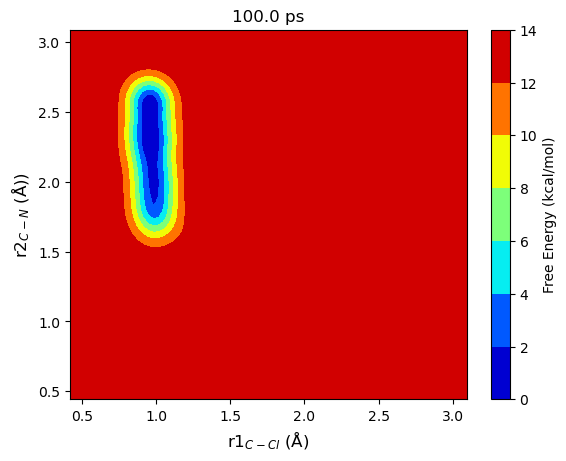

data shape:  (5852, 5)


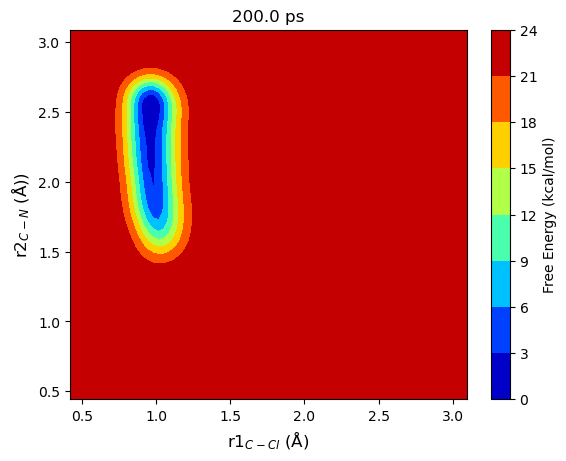

data shape:  (5852, 5)


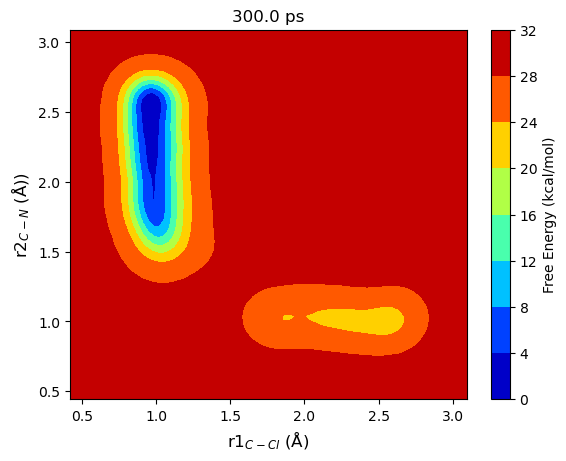

data shape:  (5852, 5)


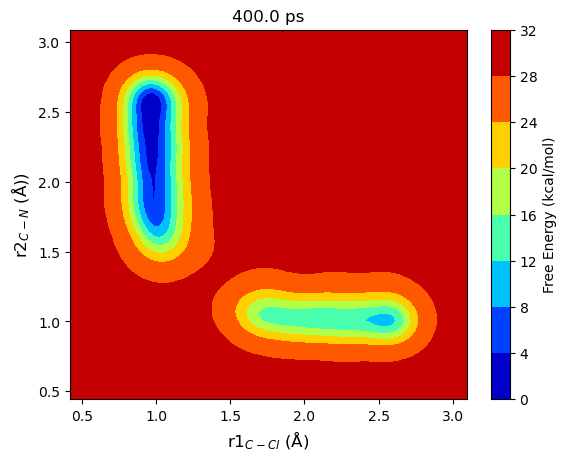

data shape:  (5852, 5)


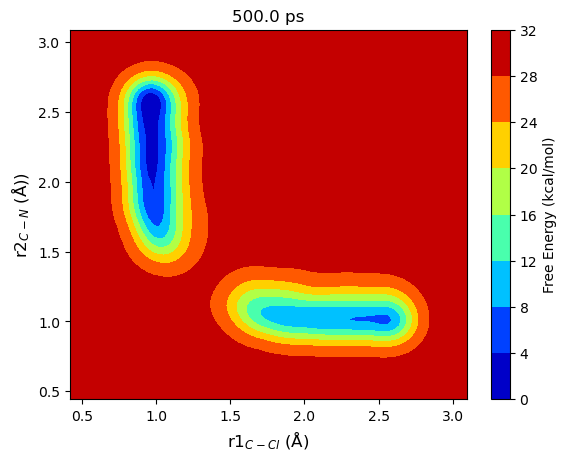

data shape:  (5852, 5)


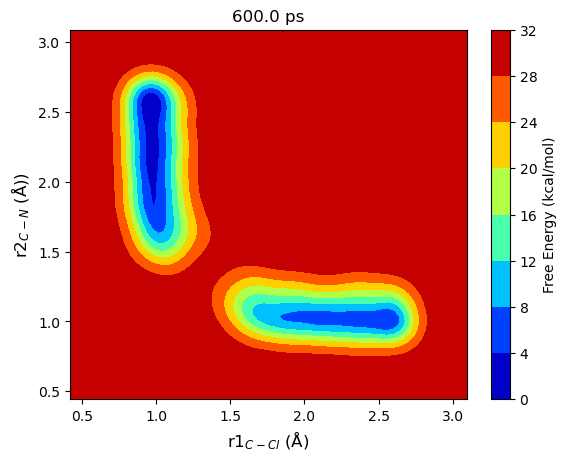

data shape:  (5852, 5)


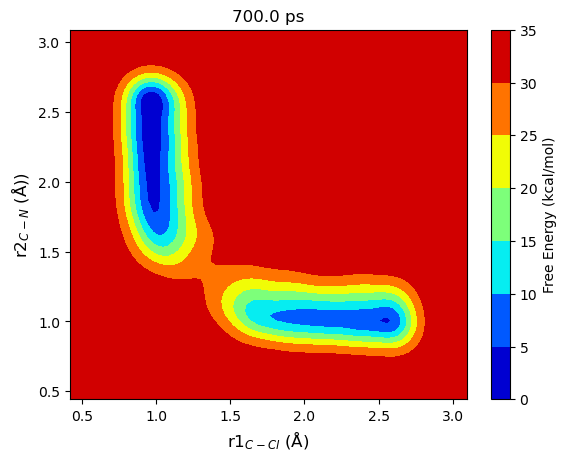

data shape:  (5852, 5)


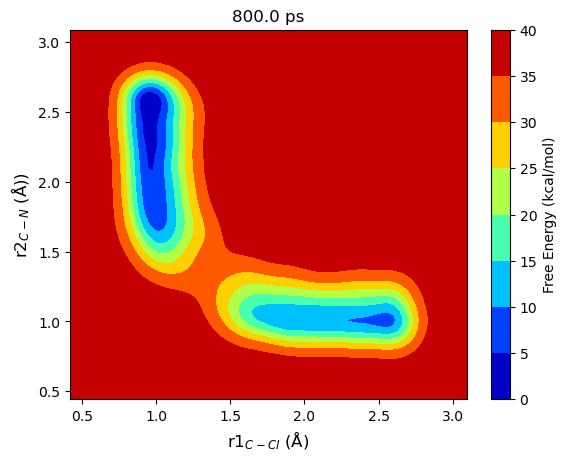

data shape:  (5852, 5)


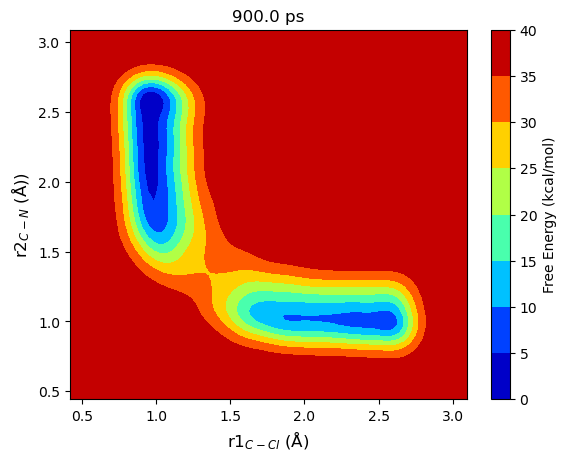

data shape:  (5852, 5)


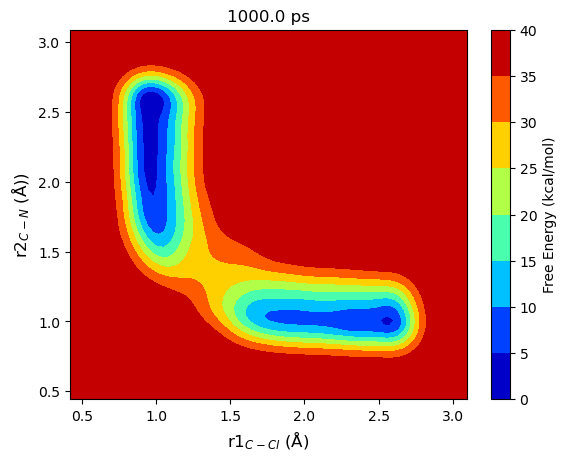

In [139]:
fnames = sorted(glob(f'{outname}_timedep?.dat'))
print('found files: ', fnames)

ii = nstlim / len(fnames)
for i,fname in enumerate(fnames):
    data = np.loadtxt(f'{fname}', comments="#")
    print('data shape: ', data.shape)
    
    r1 = data[:,0] 
    r2 = data[:,1] 
    fes = data[:,2] 
    
    r1_vals = np.unique(r1)
    r2_vals = np.unique(r2)
    F = np.full((len(r1_vals), len(r2_vals)), np.nan)
    
    r1_index = {v:i for i, v in enumerate(r1_vals)}
    r2_index = {v:i for i, v in enumerate(r2_vals)}
    
    for x,y,z in zip(r1, r2, fes):
        F[r1_index[x], r2_index[y]] = z
    
    # cp_lines = plt.contour(r1_vals, r2_vals, F.T, levels=np.arange(0,30,0.2))
    cp = plt.contourf(r1_vals, r2_vals, F.T, cmap='jet')
    plt.colorbar(cp, label='Free Energy (kcal/mol)')
    plt.xlabel('r1$_{C-Cl}$ (Å)', fontsize=12)
    plt.ylabel('r2$_{C-N}$ (Å))', fontsize=12)
    plt.title(f'{ii} ps')
    plt.savefig(f'img/fes_timedep{i}.png', dpi=300)
    ii=ii + (nstlim/len(fnames))
    plt.show()
